# 🩸 Classificação de Células Sanguíneas
**Disciplina:** Processamento de Imagens  
**Dataset:** Blood Cell Classification (Kaggle)  
**Abordagem:** Comparação entre CNN do zero, MobileNetV2 e EfficientNetB0

---
## Contexto
A identificação automática de tipos celulares em imagens microscópicas é fundamental na área médica, auxiliando no diagnóstico de doenças hematológicas. Este projeto desenvolve e compara três arquiteturas de redes neurais convolucionais para classificar automaticamente células sanguíneas em suas respectivas categorias.

**Classes do dataset:**
- EOSINOPHIL (Eosinófilo)
- LYMPHOCYTE (Linfócito)
- MONOCYTE (Monócito)
- NEUTROPHIL (Neutrófilo)

## 📦 1. Instalação e Importações

In [1]:
# Instalar dependências extras
!pip install -q kaggle grad-cam

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Usando dispositivo: cuda


## 📥 2. Download do Dataset (Kaggle)

In [2]:
from google.colab import files
print('Faça upload do seu kaggle.json:')
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/blood-cells --unzip -p ./data
print('Dataset baixado!')

Faça upload do seu kaggle.json:


Saving blood-cells-metadata.json to blood-cells-metadata.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:01<00:00, 76.8MB/s] 

Dataset baixado!


In [3]:
# Verificar estrutura do dataset
DATA_DIR = Path('./data')

# Localizar pasta de treino (estrutura pode variar)
for p in DATA_DIR.rglob('*'):
    if p.is_dir() and any(p.iterdir()):
        print(p)

# Ajuste o caminho conforme a saída acima
TRAIN_DIR = DATA_DIR / 'dataset2-master' / 'dataset2-master' / 'images' / 'TRAIN'
TEST_DIR  = DATA_DIR / 'dataset2-master' / 'dataset2-master' / 'images' / 'TEST'

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
print(f'\n📁 Classes encontradas ({NUM_CLASSES}): {CLASSES}')

# Contagem por classe
for cls in CLASSES:
    n_train = len(list((TRAIN_DIR / cls).glob('*.jpeg')) + list((TRAIN_DIR / cls).glob('*.jpg')))
    n_test  = len(list((TEST_DIR  / cls).glob('*.jpeg')) + list((TEST_DIR  / cls).glob('*.jpg')))
    print(f'  {cls}: {n_train} treino | {n_test} teste')

data/dataset2-master
data/dataset-master
data/dataset2-master/dataset2-master
data/dataset-master/dataset-master
data/dataset2-master/dataset2-master/images
data/dataset2-master/dataset2-master/images/TEST_SIMPLE
data/dataset2-master/dataset2-master/images/TRAIN
data/dataset2-master/dataset2-master/images/TEST
data/dataset2-master/dataset2-master/images/TEST_SIMPLE/LYMPHOCYTE
data/dataset2-master/dataset2-master/images/TEST_SIMPLE/NEUTROPHIL
data/dataset2-master/dataset2-master/images/TEST_SIMPLE/MONOCYTE
data/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL
data/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE
data/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL
data/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
data/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
data/dataset2-master/dataset2-master/images/TEST/LYMPHOCYTE
data/dataset2-master/dataset2-master/images/TEST/NEUTROPHIL
data/dataset2-master/dataset2-master/images/TEST/MONOCYTE
da

#exibir as imagens

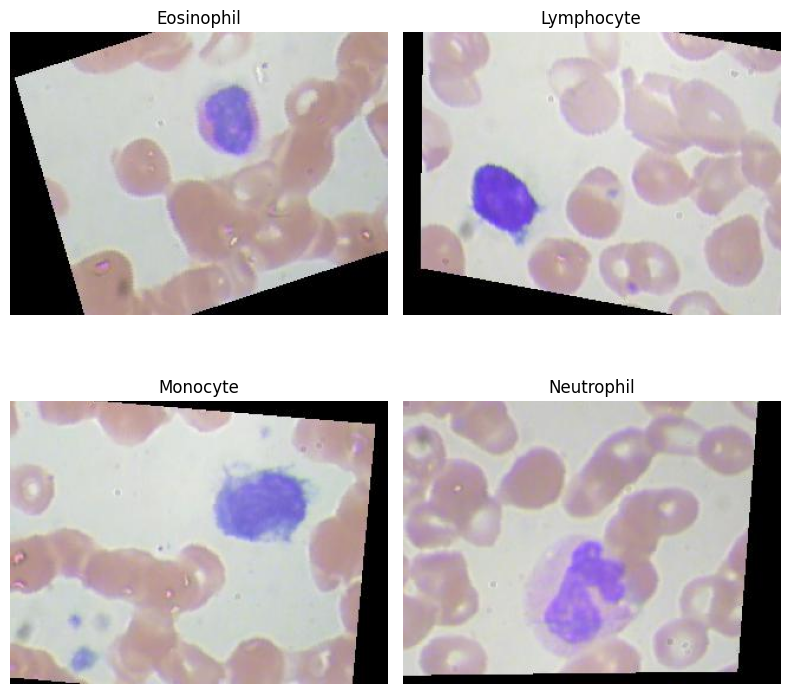

In [14]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Caminho para a pasta do dataset
dataset_path = str(TRAIN_DIR)

classes = [
    "EOSINOPHIL",
    "LYMPHOCYTE",
    "MONOCYTE",
    "NEUTROPHIL"
]

fig, axes = plt.subplots(2, 2, figsize=(8,8))

for ax, classe in zip(axes.ravel(), classes):
    pasta = os.path.join(dataset_path, classe)

    imagens = [img for img in os.listdir(pasta)
               if img.lower().endswith((".jpg", ".jpeg", ".png"))]

    img_escolhida = random.choice(imagens)

    img = Image.open(os.path.join(pasta, img_escolhida))

    ax.imshow(img)
    ax.set_title(classe.title(), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 🖼️ 3. Pré-processamento e Data Augmentation

In [4]:
IMG_SIZE = 224  # Padrão para modelos pré-treinados
BATCH_SIZE = 32

# --- Transformações de TREINO (com augmentation) ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Data Augmentation - imagens em diferentes posições pois as células rotacionam
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,   # Correção de iluminação
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    # Normalização ImageNet (usada pelos modelos pré-treinados)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Transformações de TESTE (sem augmentation) ---
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Carregar datasets
train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Treino: {len(train_dataset)} imagens | Teste: {len(test_dataset)} imagens')
print(f'Mapeamento de classes: {train_dataset.class_to_idx}')

Treino: 9957 imagens | Teste: 2487 imagens
Mapeamento de classes: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


# antes e depois

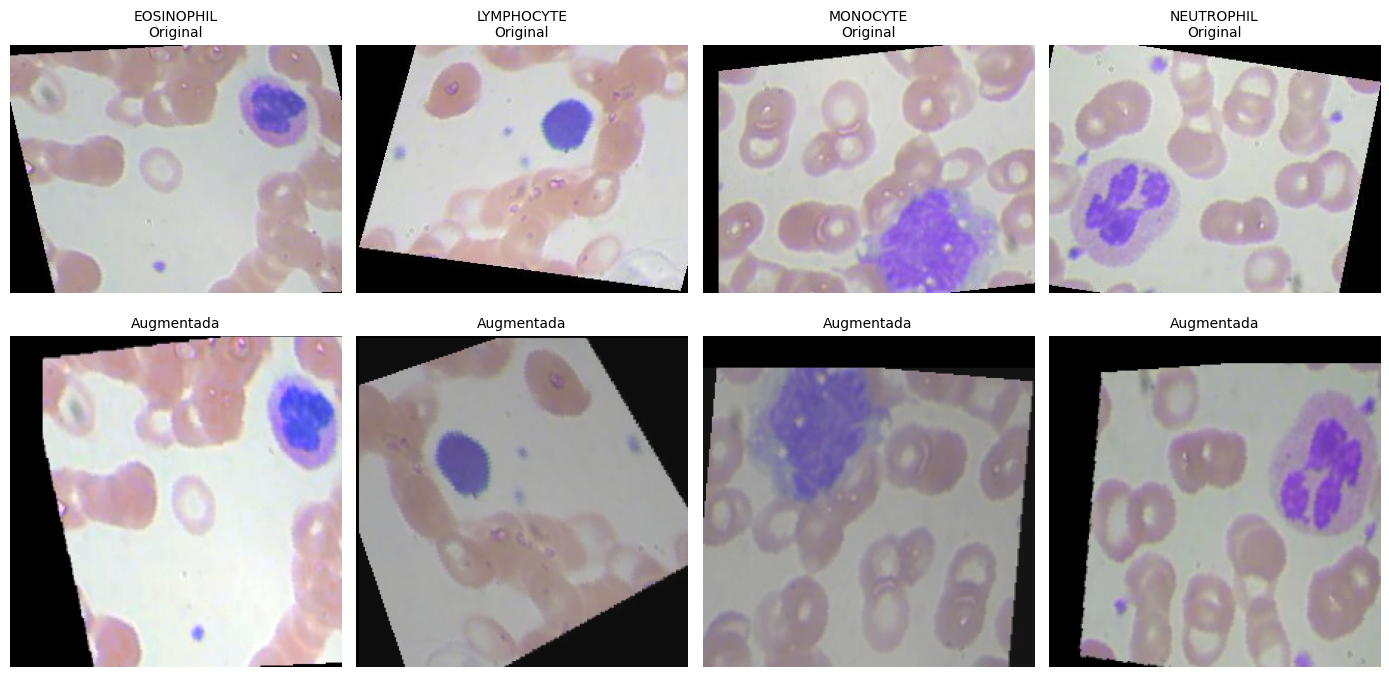

In [18]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

dataset_path = str(TRAIN_DIR)

classes = [
    "EOSINOPHIL",
    "LYMPHOCYTE",
    "MONOCYTE",
    "NEUTROPHIL"
]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1,0.1)
    )
])

fig, axes = plt.subplots(2, 4, figsize=(14,7))

for i, classe in enumerate(classes):

    pasta = os.path.join(dataset_path, classe)

    imagem = random.choice([
        img for img in os.listdir(pasta)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    original = Image.open(os.path.join(pasta, imagem)).convert("RGB")
    aumentada = transform(original)

    # Linha superior: Original
    axes[0, i].imshow(original)
    axes[0, i].set_title(f"{classe}\nOriginal", fontsize=10)
    axes[0, i].axis("off")

    # Linha inferior: Augmentada
    axes[1, i].imshow(aumentada)
    axes[1, i].set_title("Augmentada", fontsize=10)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("antes_depois.png", dpi=300)
plt.show()

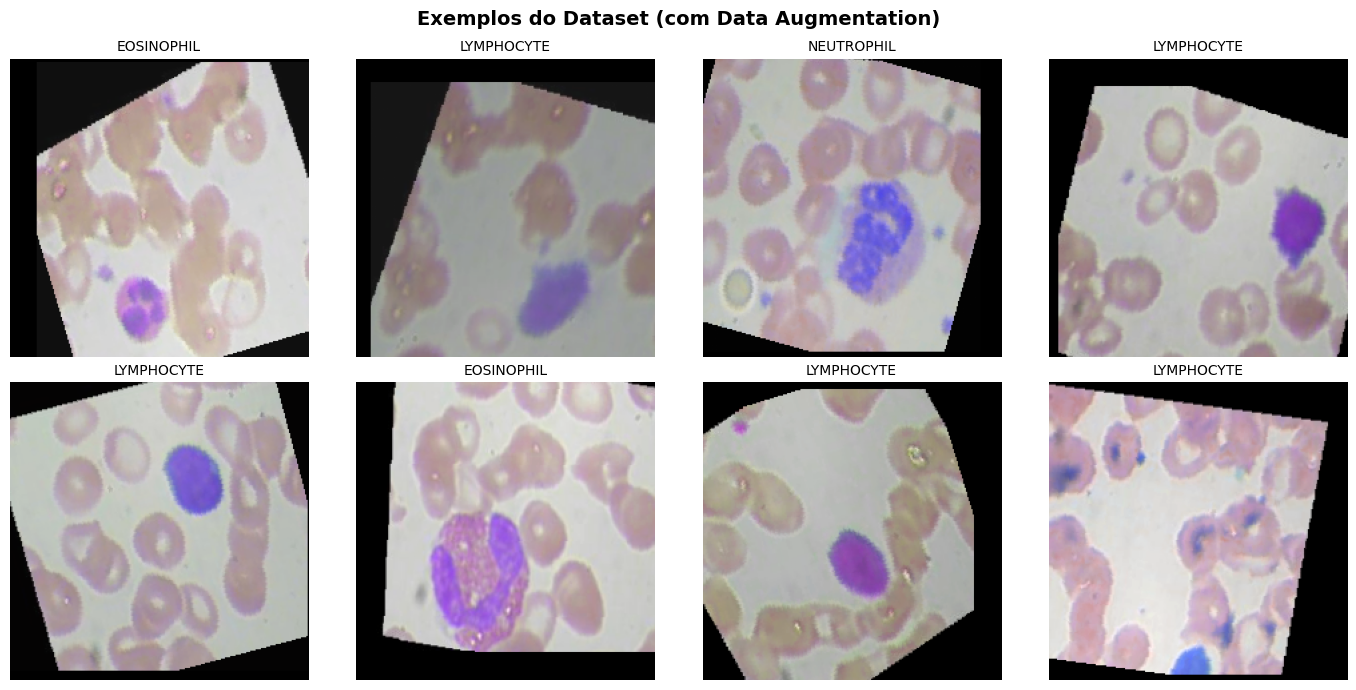

In [5]:
# Visualizar exemplos do dataset com augmentation
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Exemplos do Dataset (com Data Augmentation)', fontsize=14, fontweight='bold')

imgs, labels = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('exemplos_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏗️ 4. Definição das Arquiteturas

In [7]:
# ============================================================
# ARQUITETURA 1: CNN do Zero
# ============================================================
class CustomCNN(nn.Module):
    """CNN desenvolvida do zero com 4 blocos convolucionais."""
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        # Bloco 1: Extração de features básicas
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 224 -> 112
            nn.Dropout2d(0.1)
        )

        # Bloco 2: Features intermediárias
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 112 -> 56
            nn.Dropout2d(0.2)
        )

        # Bloco 3: Features complexas
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 56 -> 28
            nn.Dropout2d(0.3)
        )

        # Bloco 4: Features de alto nível
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 28 -> 14
        )

        # Classificador
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global Average Pooling
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


# ============================================================
# ARQUITETURA 2: MobileNetV2 (Transfer Learning)
# ============================================================
def build_mobilenet(num_classes=4, freeze_backbone=True):
    """MobileNetV2 pré-treinado no ImageNet com fine-tuning."""
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Congelar todas as camadas
        for param in model.parameters():
            param.requires_grad = False
        # Descongelar últimas 3 camadas do backbone
        for layer in list(model.features.children())[-3:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Substituir classificador final
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


# ============================================================
# ARQUITETURA 3: EfficientNetB0 (Transfer Learning)
# ============================================================
def build_efficientnet(num_classes=4, freeze_backbone=True):
    """EfficientNetB0 pré-treinado no ImageNet com fine-tuning."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        # Descongelar últimas 3 camadas
        for layer in list(model.features.children())[-3:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Substituir classificador final
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes)
    )
    return model


print('Arquiteturas definidas:')
print(f'CustomCNN | MobileNetV2 | EfficientNetB0')

Arquiteturas definidas:
CustomCNN | MobileNetV2 | EfficientNetB0


## 🔁 5. Funções de Treinamento e Avaliação

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Executa uma época de treinamento."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Avalia o modelo no conjunto de validação/teste."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels


def train_model(model, model_name, train_loader, test_loader,
                num_epochs=20, lr=1e-3, device=DEVICE):
    """Pipeline completo de treinamento com early stopping."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state, patience, no_improve = 0.0, None, 5, 0

    print(f'\nTreinando {model_name}...')
    print('─' * 60)

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Época {epoch+1:2d}/{num_epochs} | '
              f'Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        # Early stopping + salvar melhor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping na época {epoch+1}')
                break

    # Restaurar melhor estado
    model.load_state_dict(best_state)
    print(f'\n{model_name} - Melhor Val Acc: {best_acc:.4f} ({best_acc*100:.2f}%)')
    return model, history


print('Funções de treinamento definidas!')

Funções de treinamento definidas!


## 🏋️ 6. Treinamento das 3 Arquiteturas

In [12]:
# ============================================================
# Treinar CNN do zero
# ============================================================
cnn_model = CustomCNN(num_classes=NUM_CLASSES)
cnn_model, cnn_history = train_model(
    cnn_model, 'CNN do Zero',
    train_loader, test_loader,
    num_epochs=30, lr=1e-3
)


Treinando CNN do Zero...
────────────────────────────────────────────────────────────
Época  1/30 | Loss: 1.3289 | Acc: 0.3417 | Val Loss: 1.1981 | Val Acc: 0.3768
Época  2/30 | Loss: 1.1997 | Acc: 0.4374 | Val Loss: 1.0576 | Val Acc: 0.5428
Época  3/30 | Loss: 1.0948 | Acc: 0.4884 | Val Loss: 0.8657 | Val Acc: 0.5967
Época  4/30 | Loss: 0.8946 | Acc: 0.6162 | Val Loss: 0.6276 | Val Acc: 0.7575
Época  5/30 | Loss: 0.7332 | Acc: 0.6833 | Val Loss: 0.5232 | Val Acc: 0.7797
Época  6/30 | Loss: 0.6653 | Acc: 0.6987 | Val Loss: 0.5495 | Val Acc: 0.7945
Época  7/30 | Loss: 0.6193 | Acc: 0.7302 | Val Loss: 0.5889 | Val Acc: 0.7837
Época  8/30 | Loss: 0.5853 | Acc: 0.7429 | Val Loss: 0.5393 | Val Acc: 0.8002
Época  9/30 | Loss: 0.5470 | Acc: 0.7652 | Val Loss: 0.4178 | Val Acc: 0.8536
Época 10/30 | Loss: 0.5004 | Acc: 0.7896 | Val Loss: 0.4199 | Val Acc: 0.8810
Época 11/30 | Loss: 0.4766 | Acc: 0.8001 | Val Loss: 0.3096 | Val Acc: 0.8782
Época 12/30 | Loss: 0.4249 | Acc: 0.8289 | Val Loss: 0.

In [ ]:
# ============================================================
# Treinar MobileNetV2
# ============================================================
mobile_model = build_mobilenet(num_classes=NUM_CLASSES, freeze_backbone=True)
mobile_model, mobile_history = train_model(
    mobile_model, 'MobileNetV2',
    train_loader, test_loader,
    num_epochs=20, lr=1e-3
)

# Fine-tuning: descongelar todo o modelo e retreinar com LR menor
for param in mobile_model.parameters():
    param.requires_grad = True

mobile_model, mobile_history2 = train_model(
    mobile_model, 'MobileNetV2 (Fine-tuning)',
    train_loader, test_loader,
    num_epochs=10, lr=1e-4
)
# Juntar históricos
for k in mobile_history:
    mobile_history[k].extend(mobile_history2[k])

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 155MB/s]


🚀 Treinando MobileNetV2...
────────────────────────────────────────────────────────────


Época  1/20 | Loss: 0.4712 | Acc: 0.8067 | Val Loss: 0.4938 | Val Acc: 0.8464
Época  2/20 | Loss: 0.2449 | Acc: 0.9064 | Val Loss: 0.7497 | Val Acc: 0.8074
Época  3/20 | Loss: 0.1789 | Acc: 0.9338 | Val Loss: 1.6293 | Val Acc: 0.7318
Época  4/20 | Loss: 0.1346 | Acc: 0.9498 | Val Loss: 1.1050 | Val Acc: 0.8359
Época  5/20 | Loss: 0.1133 | Acc: 0.9604 | Val Loss: 1.5854 | Val Acc: 0.7531
Época  6/20 | Loss: 0.0950 | Acc: 0.9697 | Val Loss: 1.5978 | Val Acc: 0.7772
⏹️  Early stopping na época 6

✅ MobileNetV2 - Melhor Val Acc: 0.8464 (84.64%)

🚀 Treinando MobileNetV2 (Fine-tuning)...
────────────────────────────────────────────────────────────
Época  1/10 | Loss: 0.1518 | Acc: 0.9439 | Val Loss: 0.6645 | Val Acc: 0.8605
Época  2/10 | Loss: 0.0694 | Acc: 0.9752 | Val Loss: 0.9848 | Val Acc: 0.8263
Época  3/10 | Loss: 0.0377 | Acc: 0.9867 | Val Loss: 1.0528 | Val Acc: 0.8424
Época  4/10 | Loss: 0.0241 | Acc: 0.9919 | Val Loss: 1.0572 | Val Acc: 0.8376
Época  5/10 | Loss: 0.0182 | Acc: 0.99

In [ ]:
# ============================================================
# Treinar EfficientNetB0
# ============================================================
effnet_model = build_efficientnet(num_classes=NUM_CLASSES, freeze_backbone=True)
effnet_model, effnet_history = train_model(
    effnet_model, 'EfficientNetB0',
    train_loader, test_loader,
    num_epochs=20, lr=1e-3
)

# Fine-tuning
for param in effnet_model.parameters():
    param.requires_grad = True

effnet_model, effnet_history2 = train_model(
    effnet_model, 'EfficientNetB0 (Fine-tuning)',
    train_loader, test_loader,
    num_epochs=10, lr=5e-5
)
for k in effnet_history:
    effnet_history[k].extend(effnet_history2[k])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 196MB/s]


🚀 Treinando EfficientNetB0...
────────────────────────────────────────────────────────────


Época  1/20 | Loss: 0.3087 | Acc: 0.8792 | Val Loss: 0.7367 | Val Acc: 0.8689
Época  2/20 | Loss: 0.1193 | Acc: 0.9570 | Val Loss: 0.8844 | Val Acc: 0.8641
Época  3/20 | Loss: 0.0762 | Acc: 0.9746 | Val Loss: 0.5582 | Val Acc: 0.8955
Época  4/20 | Loss: 0.0528 | Acc: 0.9833 | Val Loss: 0.9394 | Val Acc: 0.8862
Época  5/20 | Loss: 0.0519 | Acc: 0.9840 | Val Loss: 0.7266 | Val Acc: 0.8782
Época  6/20 | Loss: 0.0367 | Acc: 0.9859 | Val Loss: 1.1192 | Val Acc: 0.8372
Época  7/20 | Loss: 0.0339 | Acc: 0.9887 | Val Loss: 0.9565 | Val Acc: 0.8657
Época  8/20 | Loss: 0.0174 | Acc: 0.9949 | Val Loss: 0.9685 | Val Acc: 0.8814
⏹️  Early stopping na época 8

✅ EfficientNetB0 - Melhor Val Acc: 0.8955 (89.55%)

🚀 Treinando EfficientNetB0 (Fine-tuning)...
────────────────────────────────────────────────────────────
Época  1/10 | Loss: 0.0251 | Acc: 0.9903 | Val Loss: 0.7819 | Val Acc: 0.8822
Época  2/10 | Loss: 0.0144 | Acc: 0.9952 | Val Loss: 0.9314 | Val Acc: 0.8822
Época  3/10 | Loss: 0.0118 | Acc

## 📊 7. Curvas de Aprendizado

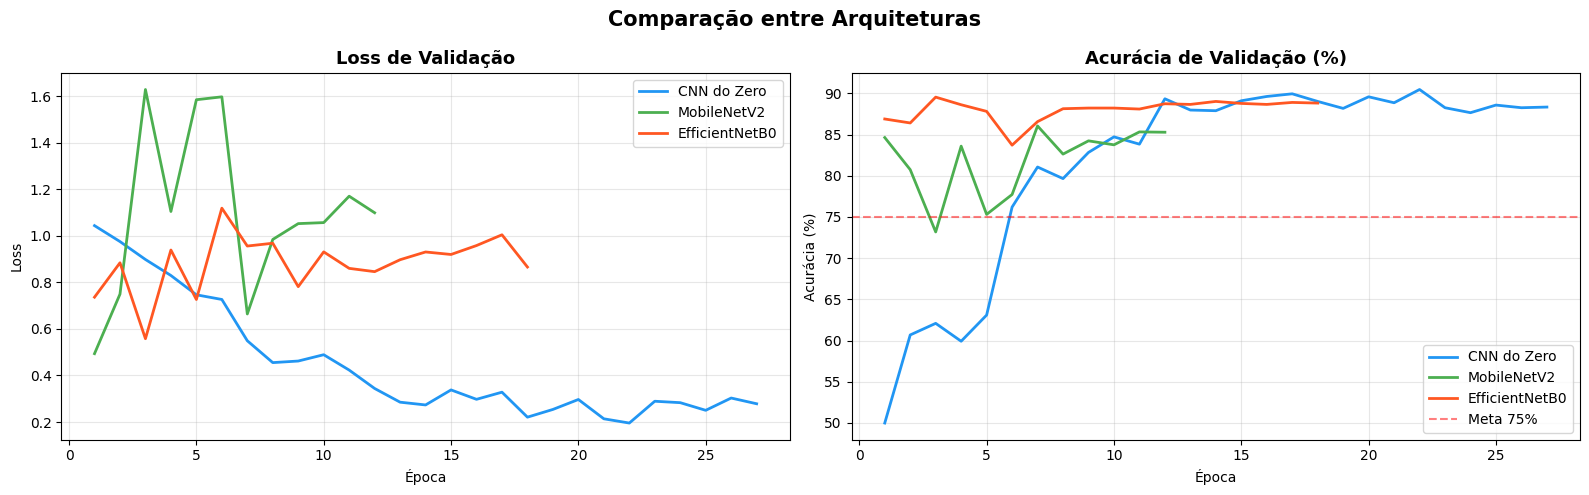

In [ ]:
def plot_history(histories, names):
    """Plota curvas de loss e acurácia para múltiplos modelos."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#2196F3', '#4CAF50', '#FF5722']

    for hist, name, color in zip(histories, names, colors):
        epochs = range(1, len(hist['train_acc']) + 1)
        axes[0].plot(epochs, hist['val_loss'], label=name, color=color, linewidth=2)
        axes[1].plot(epochs, [a*100 for a in hist['val_acc']],
                     label=name, color=color, linewidth=2)

    axes[0].set_title('Loss de Validação', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Acurácia de Validação (%)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia (%)')
    axes[1].axhline(y=75, color='red', linestyle='--', alpha=0.5, label='Meta 75%')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Comparação entre Arquiteturas', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('curvas_aprendizado.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [cnn_history, mobile_history, effnet_history],
    ['CNN do Zero', 'MobileNetV2', 'EfficientNetB0']
)

## 📈 8. Métricas Completas e Matrizes de Confusão

In [ ]:
def compute_metrics(model, loader, device, model_name):
    """Calcula e exibe todas as métricas solicitadas."""
    criterion = nn.CrossEntropyLoss()
    _, acc, preds, labels = evaluate(model, loader, criterion, device)

    precision = precision_score(labels, preds, average='weighted')
    recall    = recall_score(labels, preds, average='weighted')
    f1        = f1_score(labels, preds, average='weighted')
    cm        = confusion_matrix(labels, preds)

    print(f'\n{'='*55}')
    print(f'  📊 Métricas — {model_name}')
    print(f'{'='*55}')
    print(f'  Acurácia  : {acc*100:.2f}%')
    print(f'  Precisão  : {precision*100:.2f}%')
    print(f'  Recall    : {recall*100:.2f}%')
    print(f'  F1-Score  : {f1*100:.2f}%')
    print(f'\n{classification_report(labels, preds, target_names=CLASSES)}')

    return acc, precision, recall, f1, cm, preds, labels


# Calcular métricas para todos os modelos
results = {}
for model, name in [(cnn_model, 'CNN do Zero'),
                    (mobile_model, 'MobileNetV2'),
                    (effnet_model, 'EfficientNetB0')]:
    acc, prec, rec, f1, cm, preds, labels = compute_metrics(model, test_loader, DEVICE, name)
    results[name] = {'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1,
                     'cm': cm, 'preds': preds, 'labels': labels}


  📊 Métricas — CNN do Zero
  Acurácia  : 90.47%
  Precisão  : 90.79%
  Recall    : 90.47%
  F1-Score  : 90.56%

              precision    recall  f1-score   support

  EOSINOPHIL       0.89      0.90      0.89       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       0.96      0.88      0.91       620
  NEUTROPHIL       0.79      0.85      0.82       624

    accuracy                           0.90      2487
   macro avg       0.91      0.90      0.91      2487
weighted avg       0.91      0.90      0.91      2487


  📊 Métricas — MobileNetV2
  Acurácia  : 86.05%
  Precisão  : 87.87%
  Recall    : 86.05%
  F1-Score  : 86.26%

              precision    recall  f1-score   support

  EOSINOPHIL       0.84      0.83      0.84       623
  LYMPHOCYTE       0.98      1.00      0.99       620
    MONOCYTE       1.00      0.74      0.85       620
  NEUTROPHIL       0.70      0.86      0.77       624

    accuracy                           0.86      2487
   macro avg 

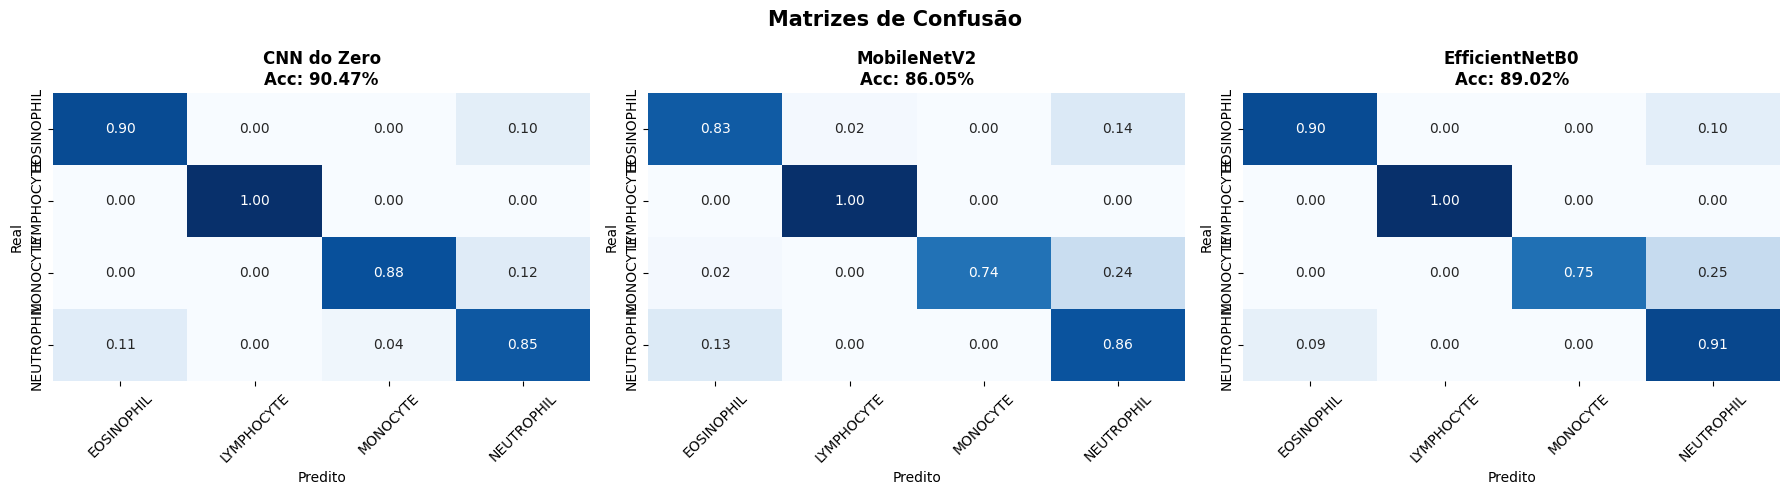

In [ ]:
# Plotar matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrizes de Confusão', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, cbar=False)
    ax.set_title(f'{name}\nAcc: {res["acc"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()


  🏆 COMPARAÇÃO FINAL ENTRE ARQUITETURAS
  Modelo                 Acurácia   Precisão     Recall         F1
-----------------------------------------------------------------
  CNN do Zero              90.47%     90.79%     90.47%     90.56%
  MobileNetV2              86.05%     87.87%     86.05%     86.26%
  EfficientNetB0           89.02%     90.81%     89.02%     89.19%


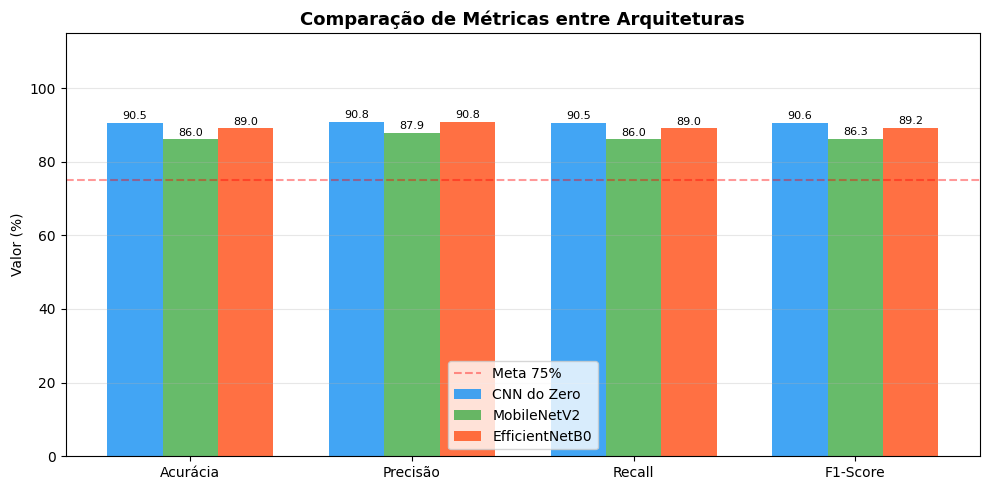

In [ ]:
# Tabela comparativa final
print('\n' + '='*65)
print('  🏆 COMPARAÇÃO FINAL ENTRE ARQUITETURAS')
print('='*65)
print(f'  {'Modelo':<20} {'Acurácia':>10} {'Precisão':>10} {'Recall':>10} {'F1':>10}')
print('-'*65)
for name, res in results.items():
    print(f'  {name:<20} {res["acc"]*100:>9.2f}% {res["precision"]*100:>9.2f}% '
          f'{res["recall"]*100:>9.2f}% {res["f1"]*100:>9.2f}%')
print('='*65)

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (name, res, color) in enumerate(zip(results.keys(), results.values(), colors)):
    vals = [res['acc'], res['precision'], res['recall'], res['f1']]
    bars = ax.bar(x + i*width, [v*100 for v in vals], width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 115)
ax.set_ylabel('Valor (%)')
ax.set_title('Comparação de Métricas entre Arquiteturas', fontsize=13, fontweight='bold')
ax.axhline(y=75, color='red', linestyle='--', alpha=0.4, label='Meta 75%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 9. Exemplos de Inferência no Conjunto de Teste

🏆 Melhor modelo: CNN do Zero


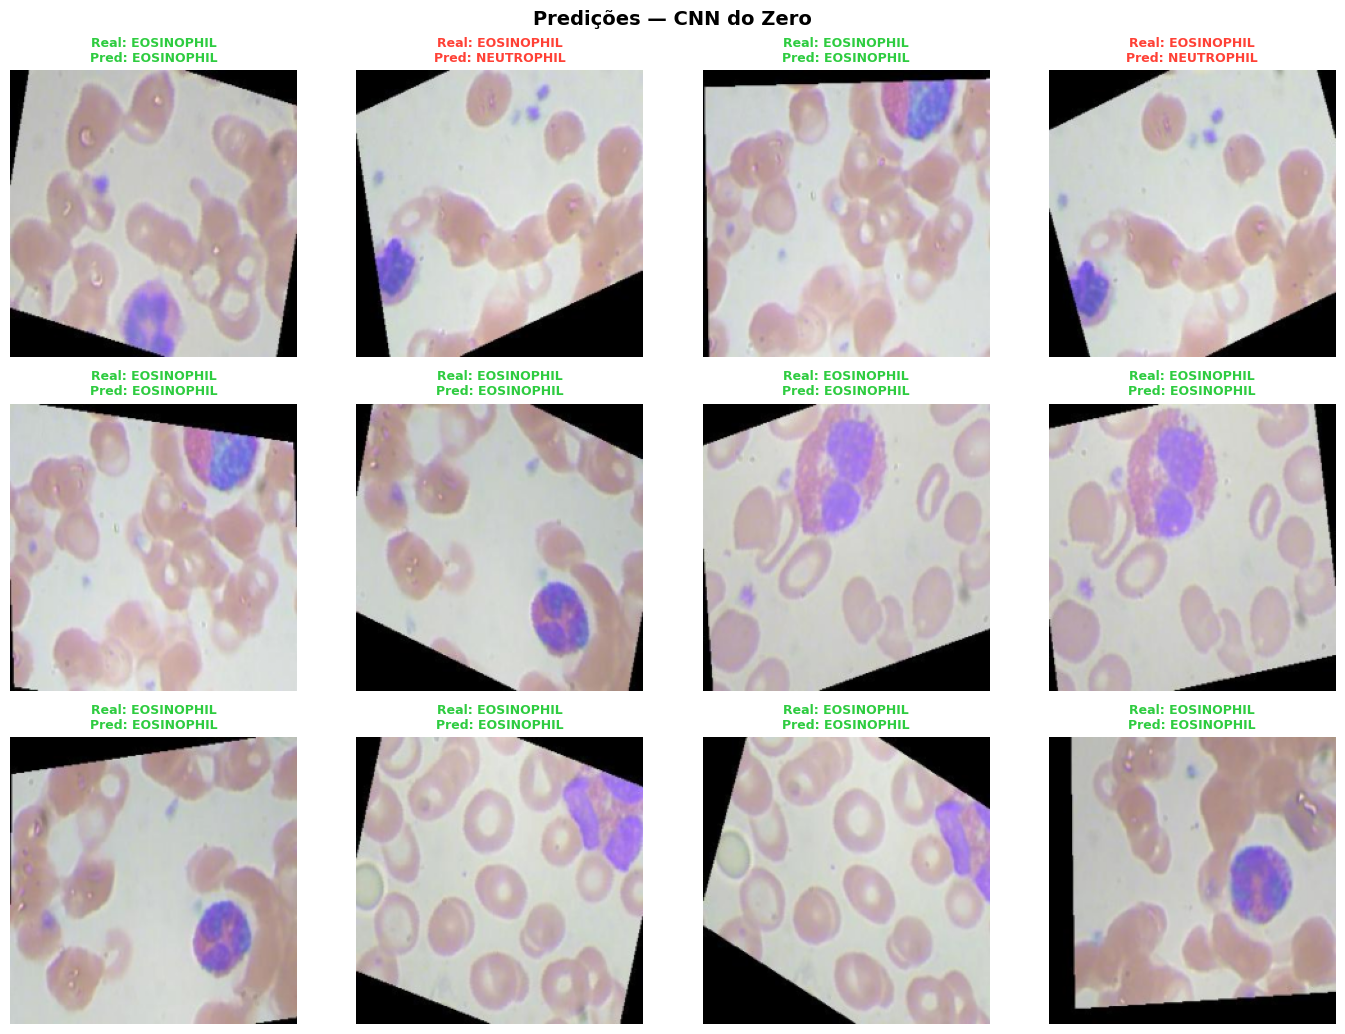

In [ ]:
def show_predictions(model, model_name, loader, device, n=12):
    """Exibe predições com indicação de acerto/erro."""
    model.eval()
    imgs_shown, preds_shown, labels_shown = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            imgs_shown.extend(imgs.cpu())
            preds_shown.extend(predicted.cpu().numpy())
            labels_shown.extend(labels.numpy())
            if len(imgs_shown) >= n:
                break

    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    fig.suptitle(f'Predições — {model_name}', fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        img = denormalize(imgs_shown[i]).permute(1, 2, 0).numpy()
        pred_name  = CLASSES[preds_shown[i]]
        label_name = CLASSES[labels_shown[i]]
        correct = preds_shown[i] == labels_shown[i]
        color = '#2ECC40' if correct else '#FF4136'
        ax.imshow(img)
        ax.set_title(f'Real: {label_name}\nPred: {pred_name}',
                     color=color, fontsize=9, fontweight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig(f'predicoes_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Mostrar predições do melhor modelo
best_model_name = max(results, key=lambda k: results[k]['acc'])
best_model = {'CNN do Zero': cnn_model,
              'MobileNetV2': mobile_model,
              'EfficientNetB0': effnet_model}[best_model_name]

print(f'🏆 Melhor modelo: {best_model_name}')
show_predictions(best_model, best_model_name, test_loader, DEVICE, n=12)

## 🎨 10. Grad-CAM — Interpretabilidade (Ponto Extra)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


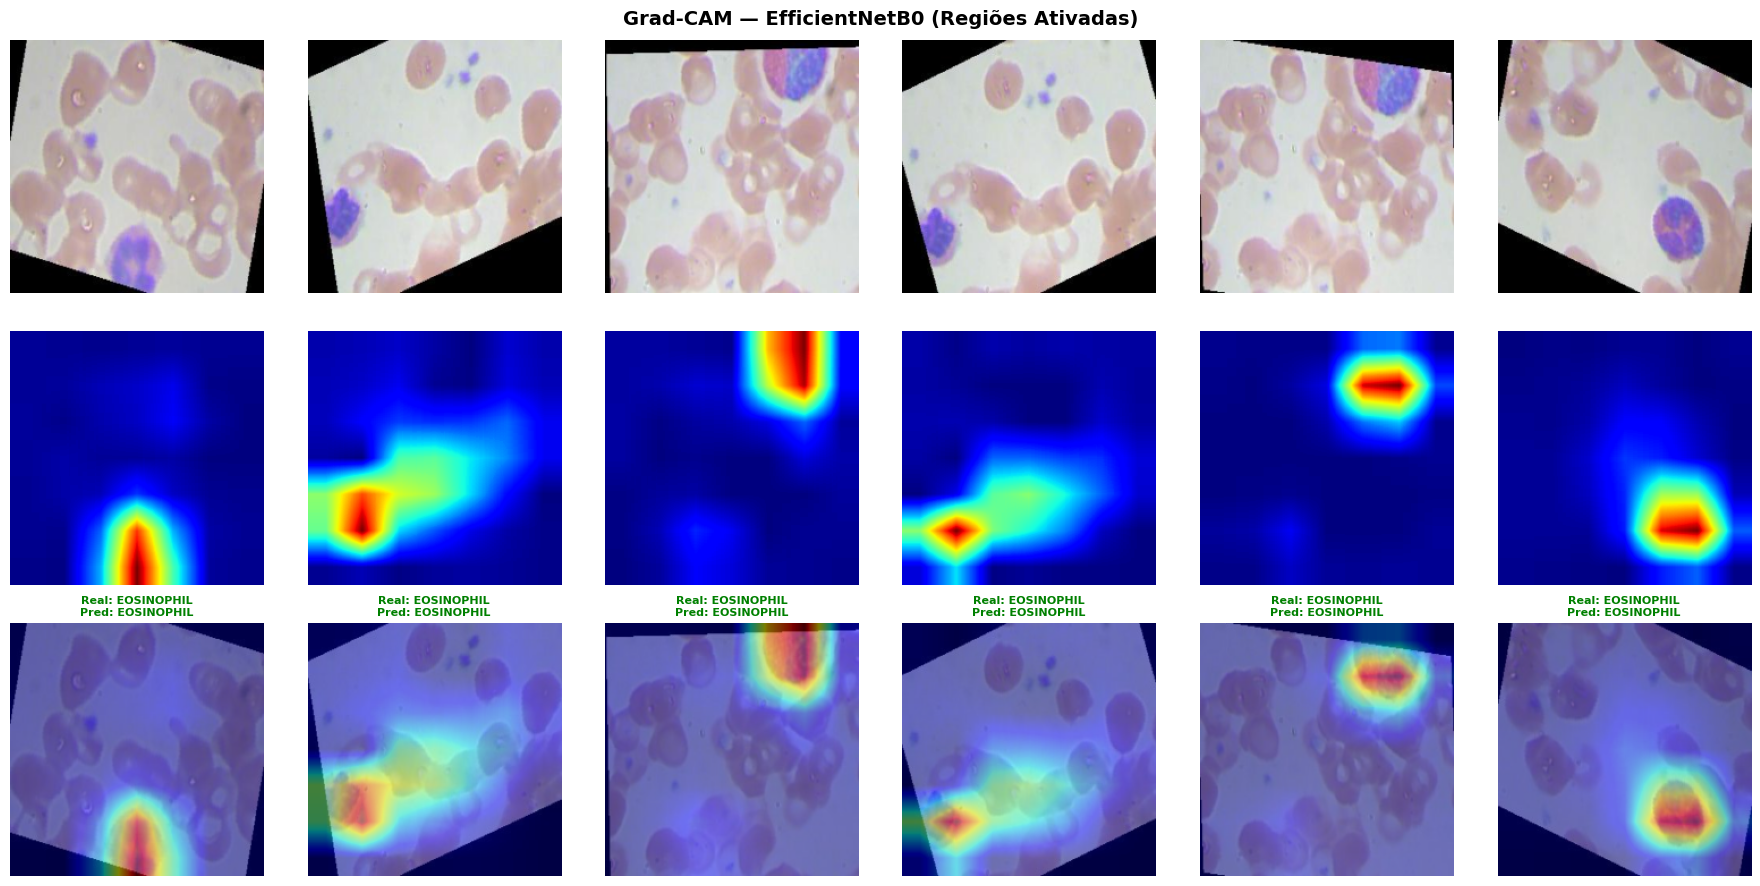

In [ ]:
import matplotlib.cm as cm

# Grad-CAM para o EfficientNetB0
class GradCAM:
    """Implementação manual do Grad-CAM."""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class


# Selecionar camada alvo do EfficientNetB0
target_layer = effnet_model.features[-1]
gradcam = GradCAM(effnet_model, target_layer)

# Visualizar Grad-CAM em 6 imagens
imgs_batch, labels_batch = next(iter(test_loader))
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Grad-CAM — EfficientNetB0 (Regiões Ativadas)', fontsize=14, fontweight='bold')

for i in range(6):
    img_tensor = imgs_batch[i:i+1].to(DEVICE)
    cam, pred_class = gradcam.generate(img_tensor)

    img_np = denormalize(imgs_batch[i]).permute(1, 2, 0).numpy()
    cam_resized = np.array(Image.fromarray(np.uint8(cam * 255)).resize(
        (IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0
    heatmap = plt.get_cmap('jet')(cam_resized)[..., :3]
    overlay = 0.5 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    label_name = CLASSES[labels_batch[i]]
    pred_name  = CLASSES[pred_class]
    color = 'green' if labels_batch[i].item() == pred_class else 'red'

    axes[0, i].imshow(img_np); axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Original', fontweight='bold')

    axes[1, i].imshow(cam_resized, cmap='jet'); axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Grad-CAM', fontweight='bold')

    axes[2, i].imshow(overlay); axes[2, i].axis('off')
    axes[2, i].set_title(f'Real: {label_name}\nPred: {pred_name}',
                          color=color, fontsize=8, fontweight='bold')
    if i == 0: axes[2, i].set_ylabel('Overlay', fontweight='bold')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## 🖥️ 11. Aplicação — Upload de Imagem para Inferência (Ponto Adicional)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Usar o melhor modelo para inferência
inference_model = best_model
inference_model.eval()

infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Widget de upload
upload_widget = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='📂 Selecionar Imagem'
)
output_widget = widgets.Output()

def on_upload(change):
    with output_widget:
        clear_output(wait=True)
        if not upload_widget.value:
            return

        # Carregar e processar imagem
        file_info = list(upload_widget.value.values())[0]
        img_bytes = file_info['content']
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        # Inferência
        tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = inference_model(tensor)
            probs = torch.softmax(output, dim=1)[0].cpu().numpy()
            pred_idx = probs.argmax()

        # Visualização
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle('🔬 Classificação de Célula Sanguínea', fontsize=13, fontweight='bold')

        axes[0].imshow(img)
        axes[0].set_title(f'Imagem enviada', fontsize=11)
        axes[0].axis('off')

        colors_bar = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(NUM_CLASSES)]
        bars = axes[1].barh(CLASSES, probs * 100, color=colors_bar)
        axes[1].set_xlabel('Confiança (%)')
        axes[1].set_title(f'✅ Predição: {CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)',
                          fontsize=11, fontweight='bold', color='#4CAF50')
        axes[1].set_xlim(0, 105)
        for bar, prob in zip(bars, probs):
            axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                         f'{prob*100:.1f}%', va='center', fontsize=10)
        axes[1].grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

upload_widget.observe(on_upload, names='value')

print('🩸 Aplicação de Classificação de Células Sanguíneas')
print(f'   Modelo: {best_model_name} | Classes: {CLASSES}')
print('   Faça upload de uma imagem de célula sanguínea para classificar:')
display(upload_widget, output_widget)

🩸 Aplicação de Classificação de Células Sanguíneas
   Modelo: CNN do Zero | Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
   Faça upload de uma imagem de célula sanguínea para classificar:


FileUpload(value={}, accept='.jpg,.jpeg,.png', description='📂 Selecionar Imagem')

Output()

## 💾 12. Salvar Modelos e Resultados

In [ ]:
# Salvar os modelos treinados
torch.save(cnn_model.state_dict(),    'modelo_cnn_do_zero.pth')
torch.save(mobile_model.state_dict(), 'modelo_mobilenetv2.pth')
torch.save(effnet_model.state_dict(), 'modelo_efficientnetb0.pth')

print('✅ Modelos salvos!')
print('\n📋 RESUMO FINAL')
print('='*55)
best = max(results.items(), key=lambda x: x[1]['acc'])
print(f'  🥇 Melhor modelo : {best[0]}')
print(f'  📊 Acurácia      : {best[1]["acc"]*100:.2f}%')
print(f'  🎯 Precisão      : {best[1]["precision"]*100:.2f}%')
print(f'  🔁 Recall        : {best[1]["recall"]*100:.2f}%')
print(f'  ⚖️  F1-Score      : {best[1]["f1"]*100:.2f}%')
print('='*55)

# Download de todos os arquivos gerados
from google.colab import files
for fname in ['curvas_aprendizado.png', 'matrizes_confusao.png',
              'comparacao_metricas.png', 'gradcam.png',
              'modelo_efficientnetb0.pth']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'  ⬇️  {fname}')

✅ Modelos salvos!

📋 RESUMO FINAL
  🥇 Melhor modelo : CNN do Zero
  📊 Acurácia      : 90.47%
  🎯 Precisão      : 90.79%
  🔁 Recall        : 90.47%
  ⚖️  F1-Score      : 90.56%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  curvas_aprendizado.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  gradcam.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  modelo_efficientnetb0.pth
